# コントロール関数多項ロジット

## 概要

多項ロジットモデルでは、説明変数（特に価格）が誤差項と相関する**内生性問題**が生じることがある。  
例えば、製品の価格は観測されない製品の質（マーケティング費用、ブランド価値など）と相関していることが多い。

この問題に対処する方法として、**コントロール関数アプローチ（Control Function Approach）**がある。  
これは Petrin & Train (2010) によって消費者選択モデルへ適用された手法で、操作変数法と最尤推定を組み合わせた2段階推定である。

## 内生性問題

### 標準的な多項ロジットの設定

消費者 $i$ が製品 $j$ を選択したときの間接効用を次のように定義する。

$$
U_{ij} = \beta^\top x_j - \alpha p_j + \xi_j + \varepsilon_{ij}
$$

- $x_j$：観測される製品属性（品質、機能など）
- $p_j$：製品 $j$ の価格
- $\xi_j$：**観測されない製品特性**（例：ブランドイメージ、広告効果）
- $\varepsilon_{ij}$：個人・製品固有のショック（第1種極値分布）

### 内生性の発生メカニズム

企業は $\xi_j$ を観察した上で価格 $p_j$ を設定するため、

$$
\text{Cov}(p_j, \xi_j) \neq 0
$$

となり、$p_j$ は**内生変数**となる。標準的な最尤推定量はこの場合に不一致推定量となる。

:::{card} 直感的な説明

質の高い製品（$\xi_j$ が大きい）は高い価格がつきやすい。もし $\xi_j$ を無視してモデルを推定すると、「価格が高い → よく売れる」という誤った因果関係を捉えてしまい、価格感応度 $\alpha$ が過小推定される。

:::

## コントロール関数アプローチ

### アイデア

内生変数 $p_j$ を外生な操作変数 $z_j$ に回帰し、その**残差**をモデルに組み込むことで、$\xi_j$ と $p_j$ の相関を「コントロール」する。

### 第1段階：価格方程式

$$
p_j = z_j^\top \gamma + \eta_j
$$

- $z_j$：操作変数（価格と相関するが $\xi_j$ と無相関な変数）
  - 例：他市場での同製品価格、原材料コスト、BLP型操作変数（他社の製品属性の平均など）
- $\eta_j$：第1段階の残差

### コントロール関数の考え方

$\xi_j$ と $p_j$ の相関構造を次のように仮定する。

$$
\xi_j = \lambda \eta_j + \tilde{\xi}_j
$$

ここで $\tilde{\xi}_j$ は $p_j$ および $z_j$ と無相関な残差である。この分解を効用に代入すると、

$$
U_{ij} = \beta^\top x_j - \alpha p_j + \lambda \eta_j + \tilde{\xi}_j + \varepsilon_{ij}
$$

$\eta_j$（第1段階残差）をモデルに追加することで、$p_j$ の内生性をコントロールできる。

### 第2段階：補正済み多項ロジット

第1段階から得られた残差 $\hat{\eta}_j$ を説明変数として追加し、多項ロジットモデルを推定する。

$$
U_{ij} = \beta^\top x_j - \alpha p_j + \lambda \hat{\eta}_j + \varepsilon_{ij}
$$

パラメータ $(\beta, \alpha, \lambda)$ を最尤法で推定する。  
$\lambda = 0$ の検定は内生性の検定としても利用できる（Hausman 型検定）。

## 推定手順

**ステップ1：第1段階の OLS 推定**

$$
\hat{\gamma} = \arg\min_\gamma \sum_j (p_j - z_j^\top \gamma)^2
$$

残差 $\hat{\eta}_j = p_j - z_j^\top \hat{\gamma}$ を計算する。

**ステップ2：拡張ロジットの最尤推定**

対数尤度関数

$$
\ell(\theta) = \sum_{i=1}^N \sum_{j=0}^J \mathbf{1}(d_i = j) \log P_{ij}(\theta)
$$

を最大化する。ここで、選択確率は

$$
P_{ij} = \frac{\exp(\beta^\top x_j - \alpha p_j + \lambda \hat{\eta}_j)}{1 + \sum_{l=1}^J \exp(\beta^\top x_l - \alpha p_l + \lambda \hat{\eta}_l)}
$$

**ステップ３：標準誤差の補正**

$\hat{\eta}_j$ は推定値であるため、第2段階の標準誤差は修正が必要である。  
一般的に**ブートストラップ標準誤差**が用いられる。

## Pythonによる実装例

In [7]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib_fontja

np.random.seed(42)

In [16]:
# =============================================
# データ生成過程
# =============================================
N = 2000   # 消費者数
J = 4      # 製品数（アウトサイド・グッズを除く）

# 真のパラメータ
alpha_true = 2.0   # 価格感応度
beta_true  = 1.5   # 製品属性への選好
lambda_true = 1.0  # 内生性の強さ

x = np.random.randn(J) # 製品属性（外生）
z = np.random.randn(J) # 操作変数（例：原材料コスト）
xi = np.random.randn(J) # 観測されない製品特性（内生性の源）

# 第1段階：価格は操作変数と xi に依存
gamma_true = 1.0
price_shock = np.random.randn(J) * 0.5
p = gamma_true * z + xi + price_shock  # xi との相関 → 内生性

# 効用（平均効用部分）
V = beta_true * x - alpha_true * p + xi  # xi は観測されない
V_aug = np.append(V, 0)                  # アウトサイド・グッズの効用 = 0

# 消費者ごとに選択をシミュレート
def simulate_choice(V_aug, N):
    eps = np.random.gumbel(size=(N, len(V_aug)))
    U = V_aug + eps
    return np.argmax(U, axis=1)

choices = simulate_choice(V_aug, N)

print(f"市場シェア（真値）:")
for j in range(J + 1):
    label = f"製品{j}" if j < J else "アウトサイド"
    print(f"  {label}: {(choices == j).mean():.3f}")

市場シェア（真値）:
  製品0: 0.006
  製品1: 0.037
  製品2: 0.015
  製品3: 0.864
  アウトサイド: 0.078


In [18]:
# =============================================
# 第1段階：価格を操作変数に回帰して残差を取得
# =============================================
# OLS: p = gamma * z + eta
gamma_hat = z @ p / z @ z
eta_hat = p - gamma_hat * z

print(f"第1段階 gamma の推定値: {gamma_hat:.3f}（真値: {gamma_true:.3f}）")
print(f"残差 eta_hat: {eta_hat}")

第1段階 gamma の推定値: 9.289（真値: 1.000）
残差 eta_hat: [-6.91922343  0.51346849 17.79569495  7.82358056]


In [10]:
# =============================================
# 第2段階：コントロール関数多項ロジット
# =============================================

def log_likelihood_cf(params, choices, x, p, eta_hat):
    """コントロール関数を含む多項ロジット対数尤度"""
    beta, alpha, lam = params
    # 各製品の平均効用
    V = beta * x - alpha * p + lam * eta_hat
    V_aug = np.append(V, 0.0)  # アウトサイド・グッズ

    # ロジット選択確率
    exp_V = np.exp(V_aug - V_aug.max())
    prob = exp_V / exp_V.sum()

    # 対数尤度
    log_lik = np.sum(np.log(prob[choices] + 1e-10))
    return -log_lik  # 最小化のため符号反転


def log_likelihood_naive(params, choices, x, p):
    """内生性を無視した標準多項ロジット対数尤度"""
    beta, alpha = params
    V = beta * x - alpha * p
    V_aug = np.append(V, 0.0)
    exp_V = np.exp(V_aug - V_aug.max())
    prob = exp_V / exp_V.sum()
    log_lik = np.sum(np.log(prob[choices] + 1e-10))
    return -log_lik


# コントロール関数モデルの推定
res_cf = minimize(
    log_likelihood_cf,
    x0=[1.0, 1.0, 0.0],
    args=(choices, x, p, eta_hat),
    method="BFGS"
)

# 内生性を無視したナイーブ推定
res_naive = minimize(
    log_likelihood_naive,
    x0=[1.0, 1.0],
    args=(choices, x, p),
    method="BFGS"
)

print("=" * 50)
print(f"真のパラメータ: beta={beta_true}, alpha={alpha_true}, lambda={lambda_true}")
print("=" * 50)
print("コントロール関数推定:")
print(f"  beta  = {res_cf.x[0]:.3f}")
print(f"  alpha = {res_cf.x[1]:.3f}")
print(f"  lambda= {res_cf.x[2]:.3f}")
print()
print("ナイーブ推定（内生性を無視）:")
print(f"  beta  = {res_naive.x[0]:.3f}")
print(f"  alpha = {res_naive.x[1]:.3f}")

真のパラメータ: beta=1.5, alpha=2.0, lambda=1.0
コントロール関数推定:
  beta  = 0.903
  alpha = 1.306
  lambda= -0.863

ナイーブ推定（内生性を無視）:
  beta  = 0.918
  alpha = 1.876


In [11]:
# =============================================
# ブートストラップによる標準誤差の計算
# =============================================

def cf_estimator(choices_b, x, p, z):
    """1回のブートストラップサンプルに対してCF推定を実行"""
    # 第1段階
    gamma_b = np.dot(z, p) / np.dot(z, z)
    eta_b = p - gamma_b * z
    # 第2段階
    res = minimize(
        log_likelihood_cf,
        x0=[1.0, 1.0, 0.0],
        args=(choices_b, x, p, eta_b),
        method="BFGS",
        options={"disp": False}
    )
    return res.x


B = 200  # ブートストラップ反復回数
boot_params = []

for _ in range(B):
    idx = np.random.choice(N, size=N, replace=True)
    choices_b = choices[idx]
    params_b = cf_estimator(choices_b, x, p, z)
    boot_params.append(params_b)

boot_params = np.array(boot_params)
boot_se = boot_params.std(axis=0)

print("ブートストラップ標準誤差（B={}）:".format(B))
print(f"  SE(beta)  = {boot_se[0]:.4f}")
print(f"  SE(alpha) = {boot_se[1]:.4f}")
print(f"  SE(lambda)= {boot_se[2]:.4f}")
print()
print("内生性の検定（lambda の t 値）:")
t_lambda = res_cf.x[2] / boot_se[2]
print(f"  lambda_hat = {res_cf.x[2]:.3f}, t = {t_lambda:.2f}")

ブートストラップ標準誤差（B=200）:
  SE(beta)  = 0.0497
  SE(alpha) = 0.2821
  SE(lambda)= 0.4309

内生性の検定（lambda の t 値）:
  lambda_hat = -0.863, t = -2.00


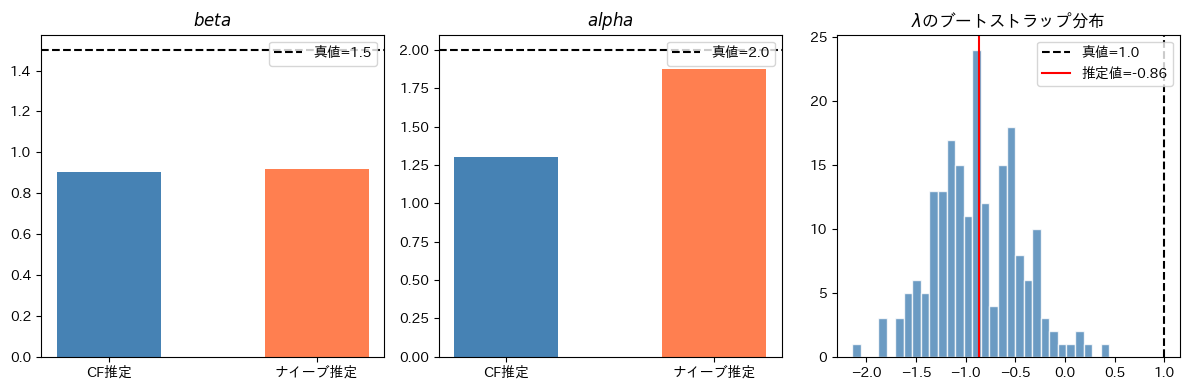

In [12]:
# =============================================
# 推定結果の比較プロット
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

param_names = ["beta", "alpha"]
true_vals = [beta_true, alpha_true]
cf_vals = res_cf.x[:2]
naive_vals = res_naive.x

for ax, name, true_v, cf_v, naive_v in zip(axes[:2], param_names, true_vals, cf_vals, naive_vals):
    ax.bar(["CF推定", "ナイーブ推定"], [cf_v, naive_v], color=["steelblue", "coral"], width=0.5)
    ax.axhline(true_v, color="black", linestyle="--", label=f"真値={true_v}")
    ax.set_title(f"${name}$")
    ax.legend()

# lambda のブートストラップ分布
ax = axes[2]
ax.hist(boot_params[:, 2], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(lambda_true, color="black", linestyle="--", label=f"真値={lambda_true}")
ax.axvline(res_cf.x[2], color="red", linestyle="-", label=f"推定値={res_cf.x[2]:.2f}")
ax.set_title(r"$\lambda$のブートストラップ分布")
ax.legend()

plt.tight_layout()
plt.show()

## IV推定との比較

内生性への対処として**操作変数法（IV）**もよく用いられる。コントロール関数アプローチとの主な違いを以下に示す。

| 観点 | コントロール関数アプローチ | 操作変数法 |
|------|--------------------------|------------|
| **推定方式** | 2段階（OLS + MLE） | GMM / 2SLS |
| **非線形モデルへの適用** | 容易（構造方程式に残差を追加するだけ） | 複雑（モーメント条件の設計が必要） |
| **内生性検定** | $\lambda = 0$ の t 検定 | Hausman 検定 |
| **標準誤差** | ブートストラップが必要 | 解析的に計算可能 |
| **一致性の条件** | 第1段階の正しい設定、誤差の線形性 | 操作変数の妥当性 |

:::{card} コントロール関数アプローチの優位性

ロジットモデルのように**非線形な構造方程式**では、操作変数法（GMM）のモーメント条件の設計が難しい。  
コントロール関数アプローチは、内生変数の残差をただ追加変数として扱えばよいため、実装が容易である。  
また、$\lambda$ の推定値は内生性の「方向と強さ」も直接教えてくれる。

:::

## 仮定と注意点

### 必要な仮定

1. **操作変数の妥当性**：$z_j$ は $\tilde{\xi}_j$ と無相関でなければならない（排除制約）
2. **第1段階の適切な設定**：$p_j$ と $z_j$ の関係が正しく線形でモデル化されていること
3. **誤差の線形性**：$\xi_j = \lambda \eta_j + \tilde{\xi}_j$ という線形分解が成立すること

### 限界

- **多数の内生変数**：内生変数が複数あると、複数の残差を追加する必要があり、推定が不安定になりやすい
- **市場水準のデータ**：集計データ（BLPのような需要推定）では追加の工夫が必要（Berry et al. の IV 条件との整合性など）
- **弱い操作変数**：第1段階の $R^2$ が低い場合、残差が不正確で一致性が損なわれる

### BLPとの関係

Berry, Levinsohn & Pakes (1995) の BLP モデルも価格の内生性を扱うが、市場シェアデータを用いた集計モデルである。  
個票データが利用可能な場合はコントロール関数アプローチが直接的に適用できる。

## 文献

- **Petrin, A. & Train, K. (2010)**. ["A Control Function Approach to Endogeneity in Consumer Choice Models."](https://doi.org/10.1509/jmkr.47.1.3) *Journal of Marketing Research*, 47(1), 3–13.
  - コントロール関数アプローチを消費者選択モデルに適用した基礎論文
- **Rivers, D. & Vuong, Q. H. (1988)**. "Limited Information Estimators and Exogeneity Tests for Simultaneous Probit Models." *Journal of Econometrics*, 39(3), 347–366.
  - プロビットモデルへのコントロール関数アプローチの先駆的研究
- **Wooldridge, J. M. (2010)**. *Econometric Analysis of Cross Section and Panel Data* (2nd ed.). MIT Press.
  - コントロール関数アプローチの一般的な理論的背景（第 8 章）
- **Berry, S., Levinsohn, J. & Pakes, A. (1995)**. "Automobile Prices in Market Equilibrium." *Econometrica*, 63(4), 841–890.
  - 集計データを用いた需要推定で内生性を扱う BLP モデル
- **Train, K. (2009)**. *Discrete Choice Methods with Simulation* (2nd ed.). Cambridge University Press.
  - [オンライン無料公開版](https://eml.berkeley.edu/books/choice2.html)